---
authors:
  - name: Ignacio Ibarra
  - name: Lukas Heumos
    roles:
      - writing – review & editing
  - name: Anna Schaar
    roles:
      - writing – review & editing
---


(mechanisms-gene-regulatory-networks)=
# Gene regulatory networks
```{dropdown} 🧠 Key takeaways

:::{card}
:link: #mechanisms-gene-regulatory-networks-key-takeaway-1
Gene regulatory networks describe which transcription factors activate or repress which target genes, and the targets of a transcription factor form its regulon.
:::

:::{card}
:link: #mechanisms-gene-regulatory-networks-key-takeaway-2
Networks inferred from expression alone recover few known interactions, so estimating transcription factor activities from a prior-knowledge network such as CollecTRI is the more robust default.
:::

```
``````{dropdown} ⚙️ Environment setup
`````{tab-set}

````{tab-item} Steps
```{include} ../_static/default_text_env_setup.md
```
````

````{tab-item} yml
```{literalinclude} gene_regulatory_networks.yml
:language: yaml
```
````

`````
``````
````{dropdown} 🗄️ Get data and notebooks
```{include} ../_static/default_text_lamindb_setup.md
```
````
<!-- END DROPDOWNS -->


(mechanisms-gene-regulatory-networks-key-takeaway-1)=
## Motivation

Transcription factors (TFs) control gene expression by binding regulatory elements near their target genes and activating or repressing their transcription.
A gene regulatory network (GRN) describes these relationships as a directed graph from TFs to their target genes, where each edge can carry a sign for activation or repression and a weight.
The set of targets of a TF is called its regulon.
GRNs help to explain which regulators establish and maintain cell identities and which regulators change between conditions.

(mechanisms-gene-regulatory-networks-key-takeaway-2)=
## Inferring gene regulatory networks

GRNs can be inferred from gene expression alone, for example with regression models that score how well each TF predicts every gene, which SCENIC then prunes with TF binding motifs {cite:p}`grn:Aibar2017-tp`.
Multimodal methods such as SCENIC+ additionally require accessible chromatin at a TF's binding site near the target {cite:p}`grn:BravoGonzalezBlas2023`, see the [chromatin accessibility chapter](../chromatin_accessibility/gene_regulatory_networks_atac.ipynb).
Alternatively, prior-knowledge networks collect TF-target interactions that were reported in the literature and in databases, such as DoRothEA {cite:p}`grn:Garcia-Alonso2019-ly` and its successor CollecTRI {cite:p}`grn:MullerDott2023`.

Networks inferred from expression alone recover known interactions barely better than random ones {cite:p}`grn:Pratapa2020-as`, and even multimodal networks change with seeds and method choices and struggle to predict the effects of perturbations {cite:p}`grn:BadiaIMompel2024`.
Unless the question is about regulation that is not yet known, we therefore recommend estimating TF activities from a prior-knowledge network {cite:p}`grn:BadiaIMompel2023`.
A TF's activity is inferred from the expression of its targets, its footprint, which is more informative than the TF's own expression, since TFs are often lowly expressed and regulated after transcription.

## Environment setup and data

We continue with sample `site4-donor8` of the NeurIPS human bone marrow dataset {cite:p}`grn:luecken2021sandbox` and use the cell type annotations curated for the challenge.

In [1]:
import decoupler as dc
import lamindb as ln
import scanpy as sc

sc.set_figure_params(dpi=80, facecolor="white", frameon=False)

ln.connect("theislab/sc-best-practices")
ln.track("s7XDZUXrhnOD")

→ connected lamindb: theislab/sc-best-practices


→ loaded Transform('s7XDZUXrhnOD0000', key='gene_regulatory_networks.ipynb'), started new Run('EA2BfGn30QGBaKwk') at 2026-09-29 13:11:49 UTC


→ notebook imports: decoupler==2.2.0 lamindb-core==2.10.0 scanpy==1.12.4


We keep the gene expression of the sample, normalize it with the shifted logarithm and compute a UMAP for visualization.

In [2]:
adata = ln.Artifact.get(
    key="cellular_structure/openproblems_bmmc_multiome_genes_filtered.h5ad"
).load()
adata = adata[adata.obs["batch"] == "s4d8", adata.var["feature_types"] == "GEX"].copy()
adata.X = adata.layers["counts"].copy()
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
adata

AnnData object with n_obs × n_vars = 9876 × 13431
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    var: 'feature_types', 'gene_id'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'pca', 'neighbors', 'umap'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
    layers: 'counts', None (.X)

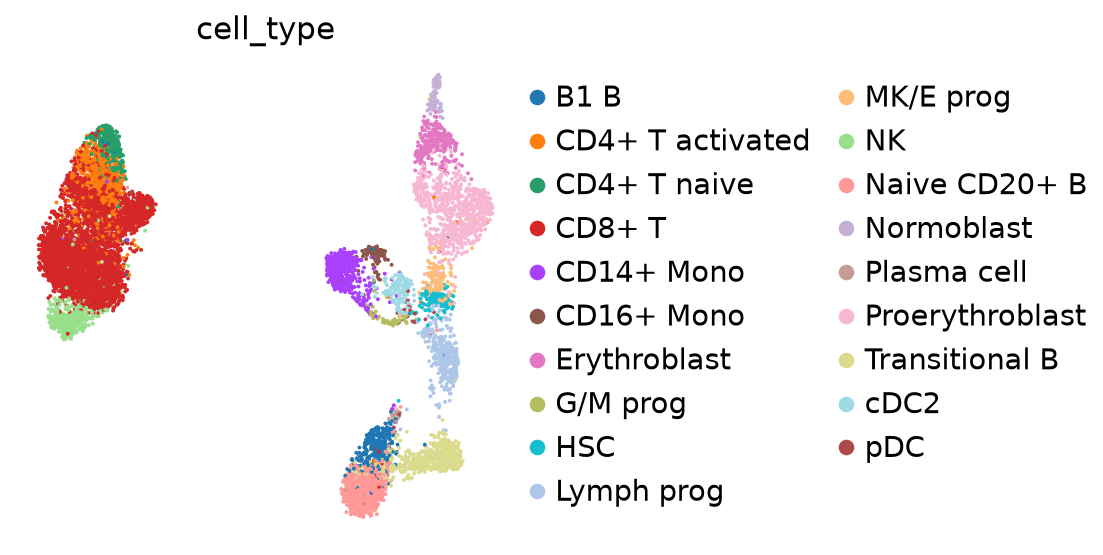

In [3]:
sc.pl.umap(adata, color="cell_type")

## A prior-knowledge network

We use CollecTRI, which gathers signed TF-target interactions for 1,186 TFs from curated databases and text mining {cite:p}`grn:MullerDott2023`, and which we already loaded in the [gene set enrichment chapter](../conditions/gsea_pathway.ipynb).
Each row is an edge from a TF (`source`) to a target gene (`target`), with a `weight` of 1 for activation and -1 for repression.

In [4]:
collectri = ln.Artifact.get(key="conditions/gsea_pathway/collectri.parquet").load()
collectri

,source,target,weight,resources,references,sign_decision
0,MYC,TERT,1.0,DoRothEA-A;ExTRI;HTRI;NTNU.Curated;Pavlidis202...,10022128;10491298;10606235;10637317;10723141;1...,PMID
1,SPI1,BGLAP,1.0,ExTRI,10022617,default activation
2,SMAD3,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
3,SMAD4,JUN,1.0,ExTRI;NTNU.Curated;TFactS;TRRUST,10022869;12374795,PMID
4,STAT5A,IL2,1.0,ExTRI,10022878;11435608;17182565;17911616;22854263;2...,default activation
...,...,...,...,...,...,...
42985,NFKB,hsa-miR-143-3p,1.0,ExTRI,19472311,default activation
42986,AP1,hsa-miR-206,1.0,ExTRI;GEREDB;NTNU.Curated,19721712,PMID
42987,NFKB,hsa-miR-21,1.0,ExTRI,20813833;22387281,default activation
42988,NFKB,hsa-miR-224-5p,1.0,ExTRI,23474441;23988648,default activation


## Transcription factor activities

decoupler {cite:p}`grn:badia2022decoupler` infers the activity of every TF in every cell with a univariate linear model (ULM) that regresses the cell's gene expression on the weights of the TF's regulon.
The t-value of the slope is the activity score: it is positive if the targets that the TF activates are expressed higher, and the targets it represses lower, than the other genes in that cell.

In [5]:
dc.mt.ulm(adata, net=collectri)
scores = dc.pp.get_obsm(adata, key="score_ulm")
scores

AnnData object with n_obs × n_vars = 9876 × 593
    obs: 'GEX_pct_counts_mt', 'GEX_n_counts', 'GEX_n_genes', 'GEX_size_factors', 'GEX_phase', 'ATAC_nCount_peaks', 'ATAC_atac_fragments', 'ATAC_reads_in_peaks_frac', 'ATAC_blacklist_fraction', 'ATAC_nucleosome_signal', 'cell_type', 'batch', 'ATAC_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker'
    uns: 'ATAC_gene_activity_var_names', 'dataset_id', 'genome', 'organism', 'log1p', 'pca', 'neighbors', 'umap', 'cell_type_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap', 'score_ulm', 'padj_ulm'
    layers: None (.X)

TF activities can be visualized like gene expression, here for the B cell regulator PAX5, the erythroid regulator GATA1 and the myeloid regulator SPI1.

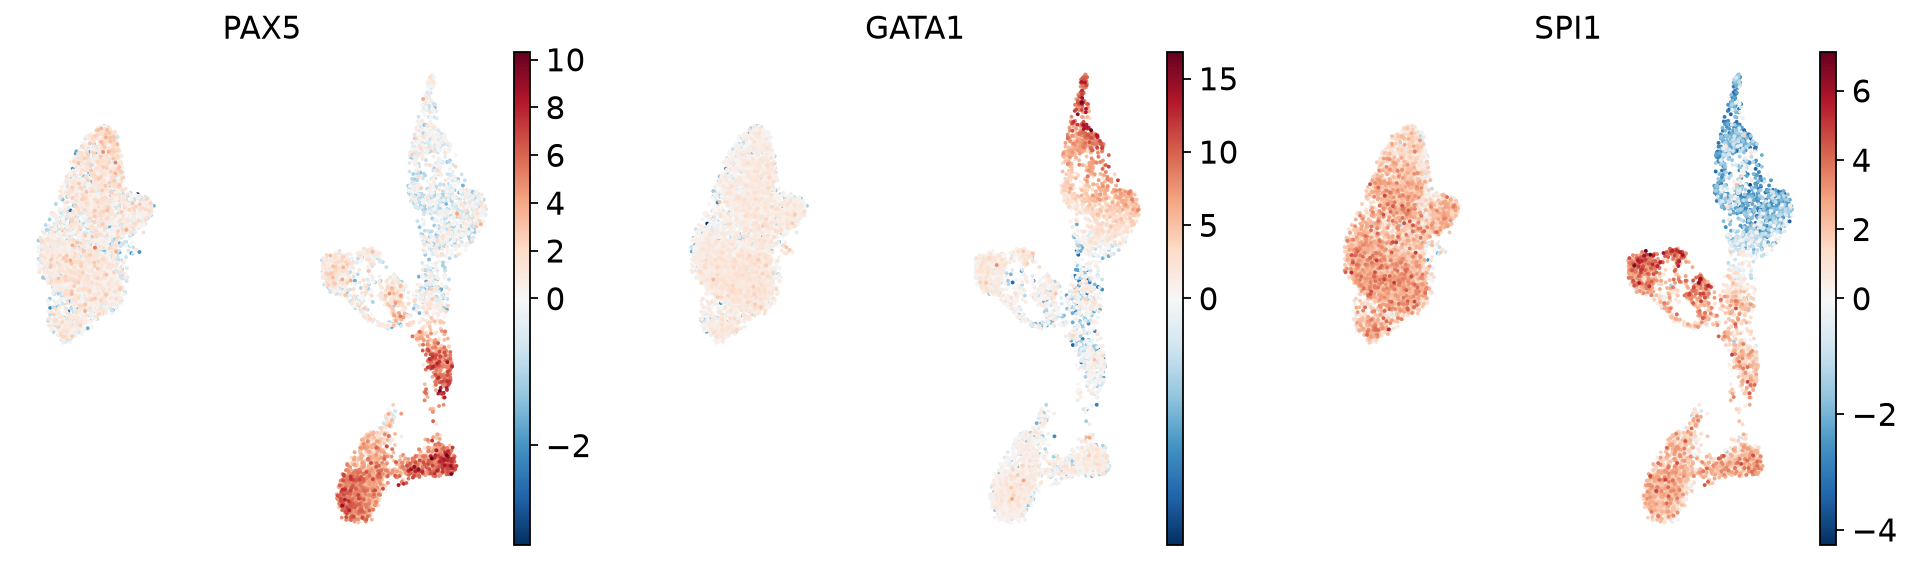

In [6]:
sc.pl.umap(scores, color=["PAX5", "GATA1", "SPI1"], cmap="RdBu_r", vcenter=0)

## Transcription factors characteristic of cell types

To find the TFs whose activity distinguishes each cell type, we rank the activity scores of every cell type against all other cells.

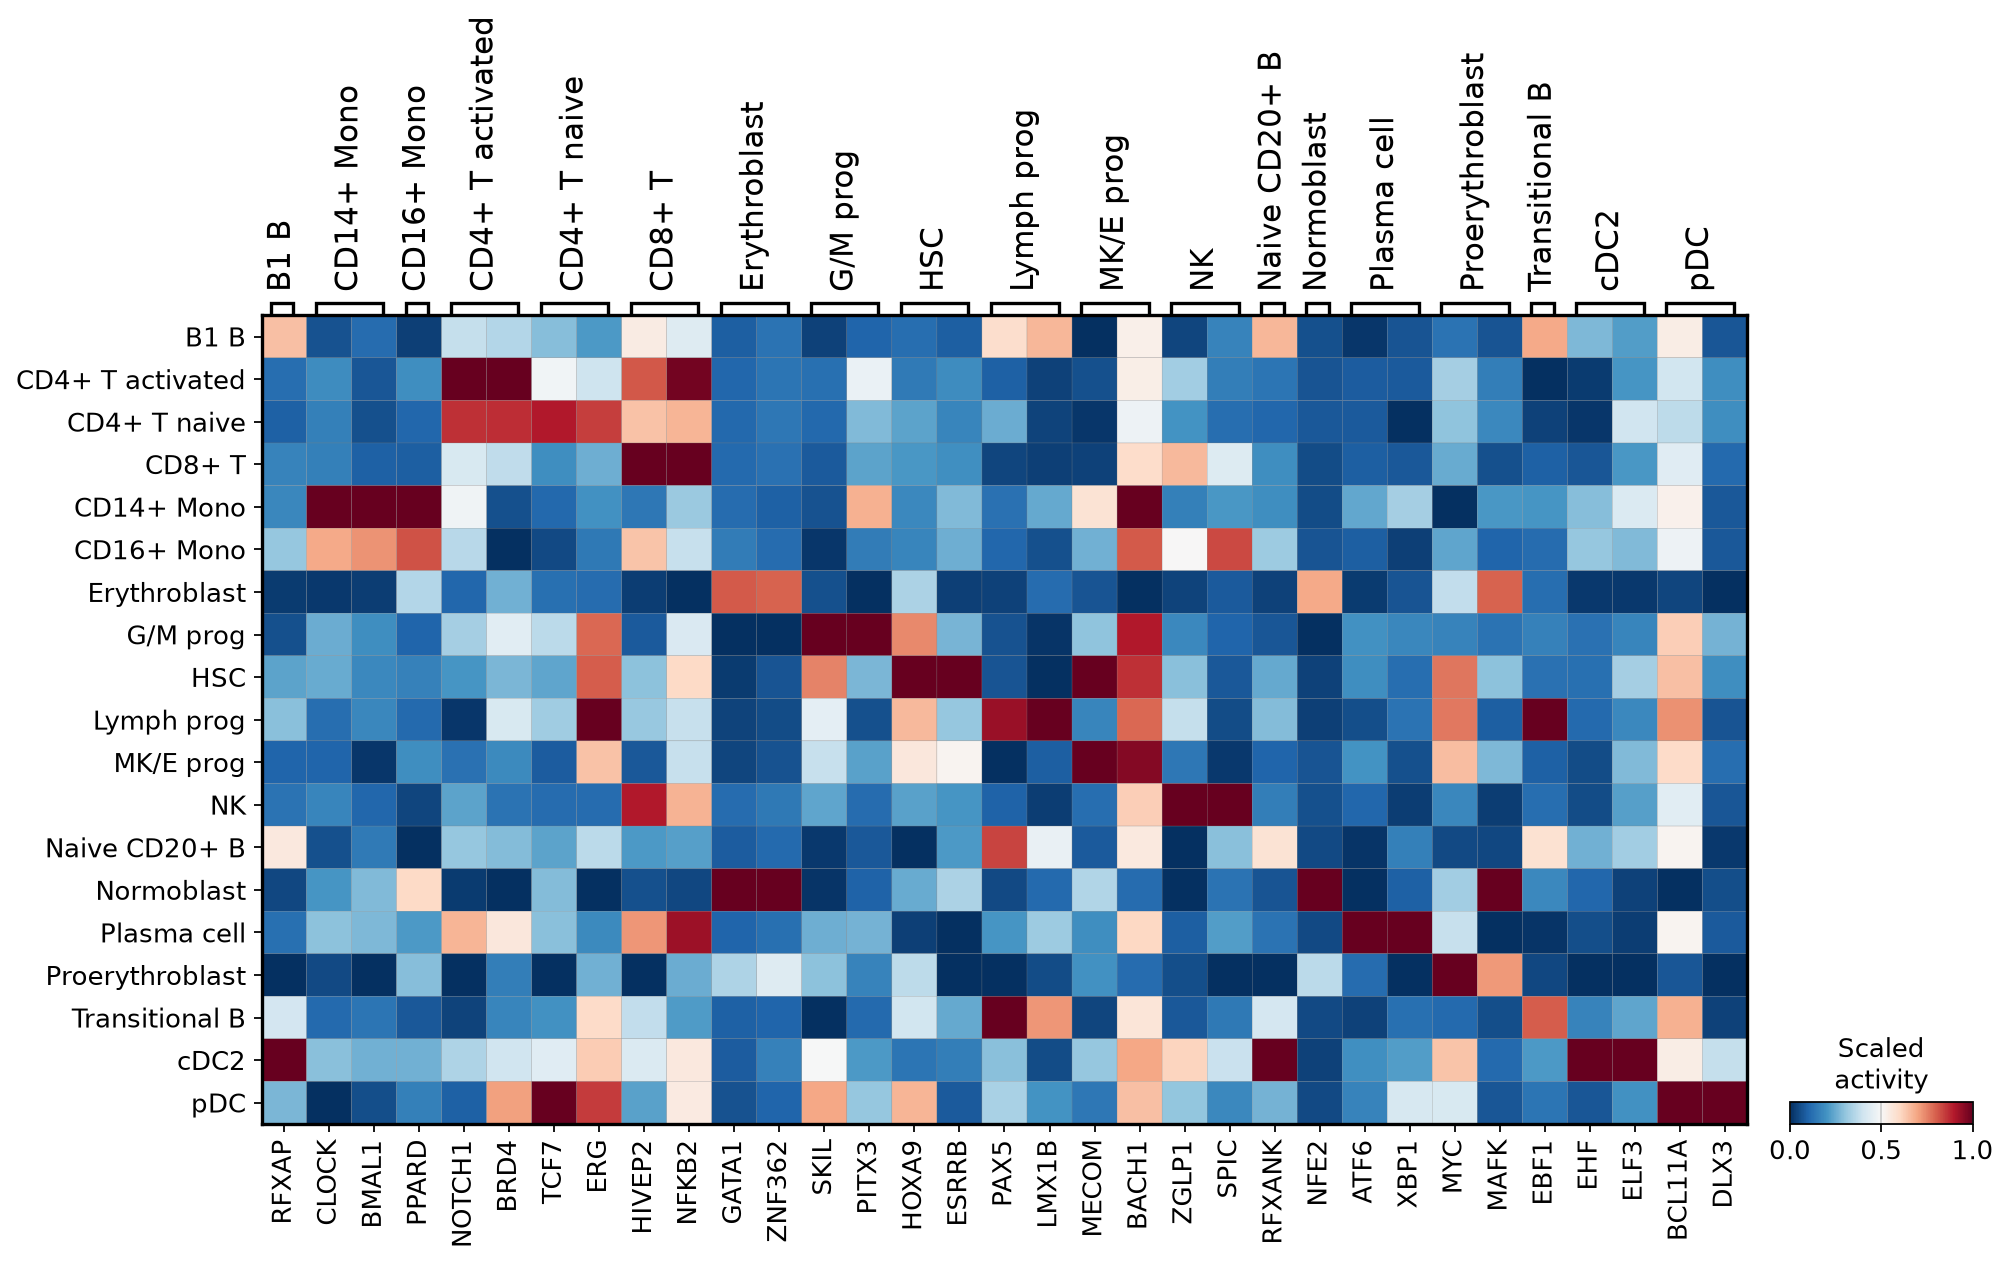

In [7]:
ranked = dc.tl.rankby_group(scores, groupby="cell_type")
top_tfs = ranked[ranked["stat"] > 0].groupby("group").head(2)
sc.pl.matrixplot(
    scores,
    top_tfs.drop_duplicates("name").groupby("group")["name"].apply(list).to_dict(),
    groupby="cell_type",
    standard_scale="var",
    cmap="RdBu_r",
    colorbar_title="Scaled\nactivity",
)

Many of these are well-known regulators, such as PAX5 and EBF1 in B cells and lymphoid progenitors, GATA1 and NFE2 in erythroid cells, HOXA9 and MECOM in HSCs, XBP1 in plasma cells, TCF7 in naive CD4+ T cells and BCL11A in pDCs.
Others, such as the circadian regulators CLOCK and BMAL1 in CD14+ monocytes, are less expected and may reflect targets they share with other TFs, so candidate regulators should be checked against known biology before they are interpreted.

## Inspecting a regulon

To see which targets drive an activity score, we plot the regulons of PAX5 and EBF1 together with the mean expression of their targets in naive B cells.

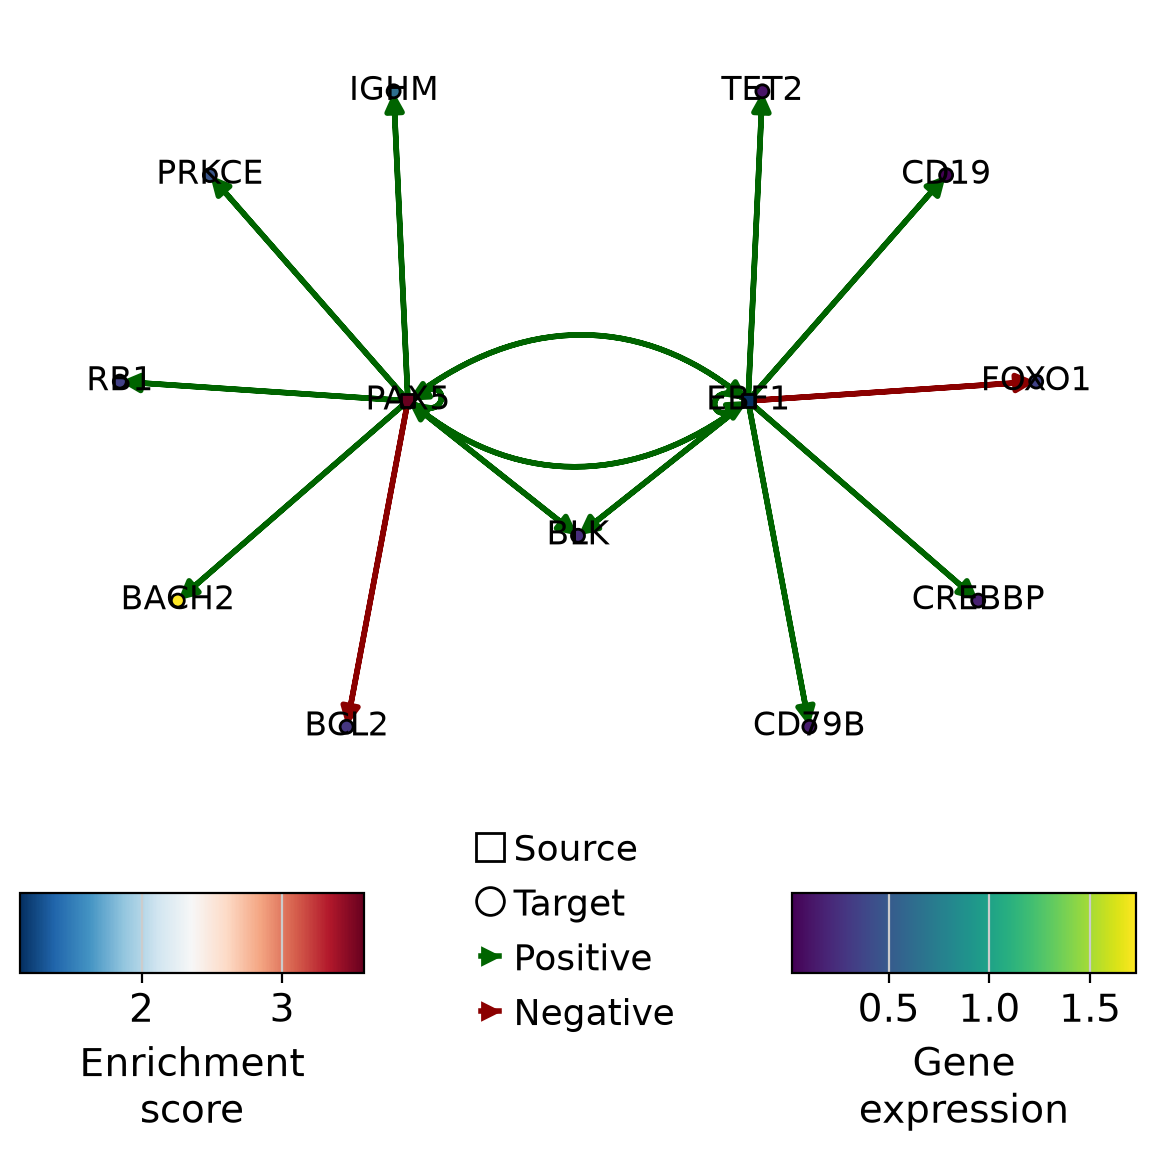

In [8]:
naive_b = adata[adata.obs["cell_type"] == "Naive CD20+ B"]
dc.pl.network(
    net=collectri,
    data=naive_b.to_df().mean().to_frame().T,
    score=dc.pp.get_obsm(naive_b, key="score_ulm").to_df().mean().to_frame().T,
    sources=["PAX5", "EBF1"],
    targets=8,
    figsize=(6, 6),
)

PAX5 and EBF1 activate each other and share targets such as BLK, and EBF1 also activates the B cell receptor components CD19 and CD79B.
Several of these targets are detected in only a few cells of this dataset, so no single target decides the activity score, which combines the evidence from the whole regulon.

## Quiz

### Theory

In [9]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card(
        "q1",
        "How many genes in the human/mouse genome are considered TFs?",
        "Approximately 1,600 genes in the human genome and 1,500 in the mouse genome encode transcription factors (TFs).",
    )
    flip_card(
        "q2",
        "What is a TF-regulon?",
        "A TF-regulon is a collection of target genes regulated by a specific transcription factor, forming a network that controls gene expression patterns.",
    )
    flip_card(
        "q3",
        "How many DNA-binding motifs are there to each TFs? Currently, are there more known DNA-binding motifs or TFs that bind those? How can one reconcile the redundancy of these during the analysis?",
        "Each TF can recognize multiple DNA-binding motifs, leading to redundancy where different TFs share motifs. Since there are more known motifs than TFs, integrating gene expression, chromatin accessibility, and TF co-binding data helps accurately map TF-target interactions.",
        front_font_size=15,
        back_font_size=15,
    )
    flip_card(
        "q4",
        "Additional reading: Describe the futility theorem.",
        "The futility theorem suggests that unbound instances of a TF's binding motif often outnumber those occupied by the TF, indicating that motif presence alone doesn't guarantee TF binding.",
        back_font_size=15,
    )

### Transcription factor activity

In [10]:
%run ../../scripts/quiz.py

with quiz_tabs():
    flip_card(
        "q1",
        "Why can the activity of a TF be more informative than its expression?",
        "TFs are often lowly expressed and regulated after transcription, for example by phosphorylation or ligand binding, so their mRNA says little about whether they act. The expression of their targets reflects the outcome of that regulation.",
        back_font_size=15,
    )
    flip_card(
        "q2",
        "What does a positive or a negative ULM activity score mean?",
        "A positive score means that the targets a TF activates are expressed higher, and those it represses lower, than the other genes in that cell, which suggests that the TF is active. A negative score suggests the opposite.",
        back_font_size=15,
    )
    flip_card(
        "q3",
        "Why do networks inferred from expression alone often disagree with known interactions?",
        "Co-expression does not imply regulation: genes can be co-expressed because they respond to the same upstream signal or mark the same cell type, and sparsity and technical noise add spurious associations.",
        back_font_size=15,
    )

## Contributors
We gratefully acknowledge the contributions of:
### Authors
* Ignacio Ibarra
### Reviewers
* Lukas Heumos
* Anna Schaar